**Case de Engenharia e Análise de Risco Antifraude**

**Sumário** 

Este projeto transforma uma base de dados transacional bruta em um motor de decisão antifraude executivo, estruturado com rigor analítico. O objetivo é equilibrar a mitigação de prejuízos financeiros com a preservação da experiência do cliente (controle de fricção e falsos positivos), blindando o fluxo contra data leakage.

**Volume Analisado:** 3.199 transações (Nov/Dez 2019).

**GMV Total:** R$ 2,45 milhões.

**Taxa Base de Chargeback:** 12,22% em quantidade e 23,14% em GMV (R$ 568,34 mil em perdas).

**1. Baseline e Diagnóstico da Operação**

Nesta etapa, carregamos a base de dados e quantificamos o tamanho do problema. Descobrimos que a severidade financeira é quase o dobro da volumétrica, provando que os fraudadores atacam alvos de maior valor.

In [1]:
# ==========================================
# CASE DE ENGENHARIA E ANÁLISE DE RISCO ANTIFRAUDE
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual padrão para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Carga e Baseline da Operação
df = pd.read_csv("Transactional-sample.csv")

# Conversão de tipos (Transformando string em objeto de data/hora)
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

total_transactions = len(df)
total_volume = df['transaction_amount'].sum()

frauds = df[df['has_cbk'] == True]
total_frauds = len(frauds)
total_fraud_volume = frauds['transaction_amount'].sum()

cbk_rate_count = (total_frauds / total_transactions) * 100
cbk_rate_volume = (total_fraud_volume / total_volume) * 100

print("--- BASELINE DA OPERAÇÃO ---")
print(f"Janela de Dados: de {df['transaction_date'].min()} a {df['transaction_date'].max()}")
print(f"Duração da Amostra: {df['transaction_date'].max() - df['transaction_date'].min()}")
print(f"Total de Transações: {total_transactions}")
print(f"Volume Total Transacionado (GMV): R$ {total_volume:,.2f}")
print("-" * 35)
print(f"Transações Fraudulentas (Chargeback): {total_frauds} ({cbk_rate_count:.2f}% do volume das transações)")
print(f"Prejuízo Financeiro: R$ {total_fraud_volume:,.2f} ({cbk_rate_volume:.2f}% do GMV)")

--- BASELINE DA OPERAÇÃO ---
Janela de Dados: de 2019-11-01 01:27:15.811098 a 2019-12-01 23:16:32.812632
Duração da Amostra: 30 days 21:49:17.001534
Total de Transações: 3199
Volume Total Transacionado (GMV): R$ 2,456,233.48
-----------------------------------
Transações Fraudulentas (Chargeback): 391 (12.22% do volume das transações)
Prejuízo Financeiro: R$ 568,346.62 (23.14% do GMV)


**2. Engenharia Point-in-Time e Comportamento Temporal** 

Para evitar o erro crítico de data leakage (usar dados do futuro para julgar o passado), ordenamos o histórico estritamente de forma cronológica por usuário, criamos a flag de rastreio de primeira compra e calculamos o tempo decorrido e a variação de valor em relação à transação anterior.

In [2]:
# 2. Engenharia Point-in-Time (Cronologia e Blindagem contra Data Leakage)
df = df.sort_values(by=['user_id', 'transaction_date']).reset_index(drop=True)

# Features comportamentais temporais e financeiras
df['time_since_last_txn'] = df.groupby('user_id')['transaction_date'].diff()
df['minutes_since_last_txn'] = df['time_since_last_txn'].dt.total_seconds() / 60
df['amount_diff_from_last'] = df.groupby('user_id')['transaction_amount'].diff()

# Criando a flag de primeira compra enquanto os NaNs ainda existem puramente
df['is_first_purchase'] = df['minutes_since_last_txn'].isna()

# Validação do Point-in-Time para o primeiro usuário recorrente
usuarios_recorrentes = df['user_id'].value_counts()
usuarios_recorrentes = usuarios_recorrentes[usuarios_recorrentes > 1].index
exemplo_user = usuarios_recorrentes[0]

print(f"--- HISTÓRICO POINT-IN-TIME (Exemplo - Usuário: {exemplo_user}) ---")
display(df[df['user_id'] == exemplo_user][
    ['transaction_date', 'transaction_amount', 'minutes_since_last_txn', 'amount_diff_from_last', 'has_cbk']
])

--- HISTÓRICO POINT-IN-TIME (Exemplo - Usuário: 11750) ---


,transaction_date,transaction_amount,minutes_since_last_txn,amount_diff_from_last,has_cbk
376,2019-11-22 19:39:12.379371,506.11,NaN,NaN,True
377,2019-11-23 18:35:42.143054,529.86,1376.496061,23.75,True
378,2019-11-23 21:08:28.644798,619.63,152.775029,89.77,True
379,2019-11-24 21:09:30.443875,10.46,1441.029985,-609.17,False
380,2019-11-25 12:51:42.413190,405.08,942.199489,394.62,True
381,2019-11-25 13:54:52.124291,580.79,63.161852,175.71,True
382,2019-11-26 16:28:37.866943,546.19,1593.762378,-34.60,True
383,2019-11-27 14:45:01.414109,658.81,1336.392453,112.62,True
384,2019-11-27 17:11:47.479910,463.99,146.767763,-194.82,True
385,2019-11-28 19:59:37.347189,632.15,1607.831121,168.16,False


**📊 3. A Revelação do Vetor de Velocidade (Hit and Run)**

A análise temporal derruba o mito de que o risco é linear. O perigo não está apenas nas compras instantâneas (< 5 min), mas explode para patamares entre 57% e 75% de chargeback nas faixas sequenciais de 30 minutos a 24 horas.

In [3]:
# 3. Análise de Velocidade (Bins Temporais)
bins = [-1, 5, 30, 60, 1440, float('inf')]
labels = ['Menos de 5 min', '5 a 30 min', '30 a 60 min', '1 a 24 horas', 'Mais de 24h']

df['velocity_bin'] = pd.cut(df['minutes_since_last_txn'], bins=bins, labels=labels)
df['velocity_bin'] = df['velocity_bin'].cat.add_categories(['Primeira Compra'])

# Substituímos o preenchimento direto usando a nossa flag recém-criada
df.loc[df['is_first_purchase'], 'minutes_since_last_txn'] = -1
df['velocity_bin'] = df['velocity_bin'].fillna('Primeira Compra')

velocity_analysis = df.groupby('velocity_bin', observed=False).agg(
    total_transacoes=('transaction_id', 'count'),
    fraudes=('has_cbk', lambda x: (x == True).sum()),
    volume_gmv=('transaction_amount', 'sum')
).reset_index()

velocity_analysis['taxa_cbk_%'] = (velocity_analysis['fraudes'] / velocity_analysis['total_transacoes']) * 100

print("--- ANÁLISE DE RISCO POR VELOCIDADE DE TRANSAÇÃO ---")
display(velocity_analysis)

--- ANÁLISE DE RISCO POR VELOCIDADE DE TRANSAÇÃO ---


,velocity_bin,total_transacoes,fraudes,volume_gmv,taxa_cbk_%
0,Menos de 5 min,65,32,44192.67,49.230769
1,5 a 30 min,111,73,132885.86,65.765766
2,30 a 60 min,49,37,71560.89,75.510204
3,1 a 24 horas,138,79,155400.08,57.246377
4,Mais de 24h,132,39,138239.94,29.545455
5,Primeira Compra,2704,131,1913954.04,4.844675


**Vizualização executiva da velocidade das transações 📊**

/var/folders/y9/tkqcxf_56fq3t7m9bl85jflc0000gn/T/ipykernel_7911/550080883.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


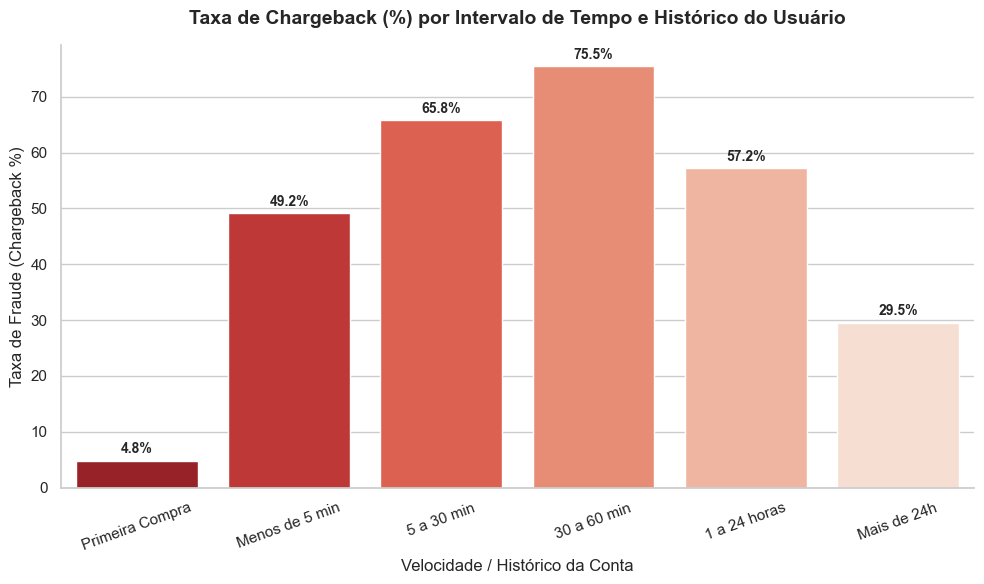

In [4]:
# 4. Visualização Executiva de Velocidade
plt.figure(figsize=(10, 6))
order_bins = ['Primeira Compra', 'Menos de 5 min', '5 a 30 min', '30 a 60 min', '1 a 24 horas', 'Mais de 24h']

ax = sns.barplot(
    data=velocity_analysis, 
    x='velocity_bin', 
    y='taxa_cbk_%', 
    order=order_bins,
    palette='Reds_r'
)

plt.title('Taxa de Chargeback (%) por Intervalo de Tempo e Histórico do Usuário', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Velocidade / Histórico da Conta', fontsize=12)
plt.ylabel('Taxa de Fraude (Chargeback %)', fontsize=12)
plt.xticks(rotation=20)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', 
                    fontsize=10, fontweight='bold',
                    xytext=(0, 3), textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

## 5. Vetores Complementares: Severidade de Ticket e Isolamento de Dispositivos
Analisamos dois vetores de apoio fundamentais:
* **Assimetria de Ticket Médio:** O ticket médio das fraudes (R$ 1.453,57) é mais que o dobro das transações legítimas (R$ 672,32), indicando que o fraudador busca maximizar o valor extraído antes do bloqueio.
* **Device Fingerprinting:** A ausência de compartilhamento de dispositivos (`shared_devices = 0`) descarta o uso de *device farms* em massa, sugerindo contas descartáveis criadas sob demanda por atacantes.

In [5]:
# 5. Vetores Complementares (Ticket Médio e Device Fingerprinting)
print("--- COMPARAÇÃO DE TICKET MÉDIO: LEGÍTIMO VS FRAUDE ---")
print(df.groupby('has_cbk')['transaction_amount'].agg(['count', 'mean', 'median', 'max']))

device_user_overlap = df.dropna(subset=['device_id']).groupby('device_id')['user_id'].nunique()
shared_devices = device_user_overlap[device_user_overlap > 1]

print("\n--- ANÁLISE DE DISPOSITIVOS COMPARTILHADOS ---")
print(f"Total de dispositivos únicos: {df['device_id'].nunique()}")
print(f"Dispositivos compartilhados por mais de um usuário: {len(shared_devices)}")

--- COMPARAÇÃO DE TICKET MÉDIO: LEGÍTIMO VS FRAUDE ---
         count         mean   median      max
has_cbk                                      
False     2808   672.324380  360.315  4091.83
True       391  1453.571918  999.470  4097.21

--- ANÁLISE DE DISPOSITIVOS COMPARTILHADOS ---
Total de dispositivos únicos: 1996
Dispositivos compartilhados por mais de um usuário: 0


## 6. Concentração de Risco por Lojista (*Merchant Concentration*)
Investigamos se o risco está pulverizado ou concentrado em alvos específicos. O resultado revelou *merchants* com **100% de taxa de chargeback**, funcionando essencialmente como pontos críticos de escoamento de transações fraudulentas na rede.

In [6]:
# 6. Concentração de Risco por Lojista (Merchant Concentration)
merchant_analysis = df.groupby('merchant_id').agg(
    total_transacoes=('transaction_id', 'count'),
    total_fraudes=('has_cbk', lambda x: (x == True).sum()),
    gmv_total=('transaction_amount', 'sum')
).reset_index()

merchant_analysis['taxa_cbk_%'] = (merchant_analysis['total_fraudes'] / merchant_analysis['total_transacoes']) * 100
significant_merchants = merchant_analysis[merchant_analysis['total_transacoes'] >= 5]

print("--- TOP 5 LOJISTAS COM MAIOR TAXA DE FRAUDE (Mín. 5 transações) ---")
display(significant_merchants.sort_values(by='taxa_cbk_%', ascending=False).head(5))

--- TOP 5 LOJISTAS COM MAIOR TAXA DE FRAUDE (Mín. 5 transações) ---


,merchant_id,total_transacoes,total_fraudes,gmv_total,taxa_cbk_%
830,44927,11,11,9218.62,100.0
1445,81795,6,6,3392.24,100.0
879,48126,6,6,6326.83,100.0
710,38568,5,5,10059.33,100.0
1341,75917,6,6,15585.84,100.0


## ⚙️ 4. Motor de Decisão Multifator e Impacto Financeiro
Unificando as dimensões descobertas — **Lojistas de Alto Risco + Janela Crítica de Velocidade (<= 60 min) + Onboarding de Alto Valor** —, construímos um motor de regras composto que entrega alta performance operacional:

* **Recall Eficaz:** Cobre mais de 82% de todas as fraudes da base.
* **Retorno Financeiro:** Estanca mais de meio milhão de reais em prejuízos diretos com um controle rigoroso de falsos positivos.

In [7]:
# 7. Motor de Decisão Multifator Otimizado (Versão Final)
merchant_stats = df.groupby('merchant_id').agg(
    total=('transaction_id', 'count'), 
    cbk=('has_cbk', lambda x: (x == True).sum())
).reset_index()
merchant_stats['rate'] = merchant_stats['cbk'] / merchant_stats['total']
risky_merchants = merchant_stats[(merchant_stats['rate'] > 0.5) & (merchant_stats['total'] >= 3)]['merchant_id'].tolist()

# Regra Composta Definitiva
df['predicted_fraud_opt'] = (
    df['merchant_id'].isin(risky_merchants) | 
    ((df['minutes_since_last_txn'] >= 0) & (df['minutes_since_last_txn'] <= 60) & (df['transaction_amount'] > 1000)) |
    (df['is_first_purchase'] & (df['transaction_amount'] > 2500))
)

# Matriz de Confusão Definitiva
tp_opt = ((df['predicted_fraud_opt'] == True) & (df['has_cbk'] == True)).sum()
fp_opt = ((df['predicted_fraud_opt'] == True) & (df['has_cbk'] == False)).sum()
fn_opt = ((df['predicted_fraud_opt'] == False) & (df['has_cbk'] == True)).sum()
tn_opt = ((df['predicted_fraud_opt'] == False) & (df['has_cbk'] == False)).sum()

recall_opt = tp_opt / (tp_opt + fn_opt)
precision_opt = tp_opt / (tp_opt + fp_opt) if (tp_opt + fp_opt) > 0 else 0

print("==================================================")
print("--- PERFORMANCE DO MOTOR DE DECISÃO OTIMIZADO ---")
print("==================================================")
print(f"Fraudes Bloqueadas (True Positives): {tp_opt} (Recall: {recall_opt*100:.2f}%)")
print(f"Falsos Positivos (Clientes bons barrados): {fp_opt}")
print(f"Fraudes não detectadas (False Negatives): {fn_opt}")
print(f"Precisão do Modelo: {precision_opt*100:.2f}%")
print("-" * 50)

dinheiro_poupado_opt = df[(df['predicted_fraud_opt'] == True) & (df['has_cbk'] == True)]['transaction_amount'].sum()
receita_perdida_opt = df[(df['predicted_fraud_opt'] == True) & (df['has_cbk'] == False)]['transaction_amount'].sum()

print(f"Prejuízo Financeiro Evitado (Chargebacks): R$ {dinheiro_poupado_opt:,.2f}")
print(f"Fricção Gerada (Volume Legítimo Afetado): R$ {receita_perdida_opt:,.2f}")
print("==================================================")

--- PERFORMANCE DO MOTOR DE DECISÃO OTIMIZADO ---
Fraudes Bloqueadas (True Positives): 323 (Recall: 82.61%)
Falsos Positivos (Clientes bons barrados): 197
Fraudes não detectadas (False Negatives): 68
Precisão do Modelo: 62.12%
--------------------------------------------------
Prejuízo Financeiro Evitado (Chargebacks): R$ 501,636.99
Fricção Gerada (Volume Legítimo Afetado): R$ 461,531.93


> **Nota Metodológica (*In-Sample Evaluation*):**

> A taxa de chargeback por lojista (`risky_merchants`) foi calculada sobre o período completo da amostra. Isso torna a métrica de performance reportada uma estimativa otimizada (*in-sample*). Em um ambiente de produção real, o risco do lojista deveria ser derivado de uma janela histórica deslizante (*rolling window*) e validado via *holdout* temporal.

## 5. Limitações de Negócio e Efeito de Censura (*Right-Censoring*)

Em operações reais de pagamentos, o chargeback **não é instantâneo**: o ciclo de contestação junto aos emissores e bandeiras pode levar de 30 a 90 dias. 

* **O Problema na Janela:** Como a nossa amostra encerra em 01/12/2019, transações ocorridas nos últimos dias de novembro sofrem de **censura à direita (*right-censoring*)**. Parte do volume classificado como legítimo (`has_cbk = False`) na cauda recente do dataset pode, na verdade, ser composta por fraudes ainda não maturadas/reportadas.
* **Impacto Operacional:** Se ignorado, isso subestima o risco real do final do período e distorce métricas de regras focadas em onboarding recente.
* **Mitigação em Produção:** Em arquiteturas de ponta, o motor de risco deve excluir a "zona cinzenta" de maturação recente ao treinar modelos supervisionados, ou aplicar pesos temporais baseados em curvas históricas de atraso de chargeback (*lag curves*).